<a href="https://colab.research.google.com/github/winzepz/Artificial-Intelligence-and-Machine-Learning/blob/main/Keras%20%26%20Image%20Classification%20with%20FCN_W4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [17]:
print("Unzipping dataset...")
!mkdir -p /content/dataset # Ensure the destination directory exists
!unzip -q "/content/drive/MyDrive/Colab Notebooks/AI and Machine Learning/Week4/Copy of devnagari digit.zip" -d "/content/dataset"
print("Unzip complete!")

Unzipping dataset...
Unzip complete!


In [5]:
!ls -R "/content/drive/MyDrive/"

ls: cannot access '/content/drive/MyDrive/': No such file or directory


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/AI and Machine Learning/Week4"))

['Copy of devnagari digit.zip', 'Darwin_W4.ipynb']


### **Task 1: Load and Prepare the Data**



In [10]:
import numpy as np
from PIL import Image
from keras.utils import to_categorical

In [20]:
import numpy as np
from PIL import Image
from keras.utils import to_categorical

def load_data(base_path, folder_name):
  X,y = [], []
  folder_path = os.path.join(base_path, folder_name)

  #loop through digits 10 to 9
  for label in range(10):
    #looks specifically for folders named digit_0...
    class_folder = os.path.join(folder_path, f"digit_{label}")

    if not os.path.exists(class_folder):
      continue
# Iterate through each class subdirectory and check if each image is valid.
    for img_name in os.listdir(class_folder):
      img_path = os.path.join(class_folder, img_name)
      try:
        #open, convert to grayscale, resize to 28x28
        img = Image.open(img_path).convert('L').resize((28,28))
        #Normalize pixels to 0-1 range
        img_array = np.array(img) / 255.0
        X.append(img_array)
        y.append(label)
      except Exception as e:
        pass
  return np.array(X), np.array(y)

#path of unzipped folder
dataset_path = "/content/dataset/DevanagariHandwrittenDigitDataset"

print("Loading training data...")
X_train, y_train = load_data(dataset_path, "Train")

print("Loading testing data...")
X_test, y_test = load_data(dataset_path, "Test")

#one hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Loading training data...
Loading testing data...
Training data shape: (17000, 28, 28)
Testing data shape: (3000, 28, 28)


Task 2: Build the FCN Model

In [21]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# create a sequential model
model = Sequential()

#flatten the 28x28 images into a 1D array of 784 pixels
model.add(Flatten(input_shape=((28,28))))

#add first hidden layer: 64 neurons, sigmoid activation
model.add(Dense(64, activation='sigmoid'))

#add 2nd hidden layer: 128 neurons,
model.add(Dense(128, activation='sigmoid'))

#add 3rd hidden layer: 256 neurons, sigmoid activation
model.add(Dense(256, activation='sigmoid'))

#add output layer: 10 units (for 10 classes), softmax activation
model.add(Dense(10, activation='softmax'))

#print out a blueprint of newly created brain
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## **Task 3: Compile the Model**

In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Task 4: Train the Model**

In [23]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

#define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4),# Stop if no improvement for 4 epochs
    ModelCheckpoint(filepath='best_devnagari_model.keras', save_best_only=True)
]

#Train
history = model.fit(
    X_train, y_train,
    epochs = 20,
    batch_size = 128,
    validation_split=0.2,
    callbacks = callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4422 - loss: 1.7047 - val_accuracy: 0.0000e+00 - val_loss: 7.1583
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8349 - loss: 0.5786 - val_accuracy: 0.0000e+00 - val_loss: 8.2898
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9305 - loss: 0.2682 - val_accuracy: 0.0000e+00 - val_loss: 8.8728
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9515 - loss: 0.1786 - val_accuracy: 0.0000e+00 - val_loss: 9.3709
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9607 - loss: 0.1374 - val_accuracy: 0.0000e+00 - val_loss: 9.6146


## **Task 5: Evaluate the Model**

In [24]:
#evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7660 - loss: 2.0368

Final Test Accuracy: 0.7660
Final Test Loss: 2.0368


## Deliverable: Visualization

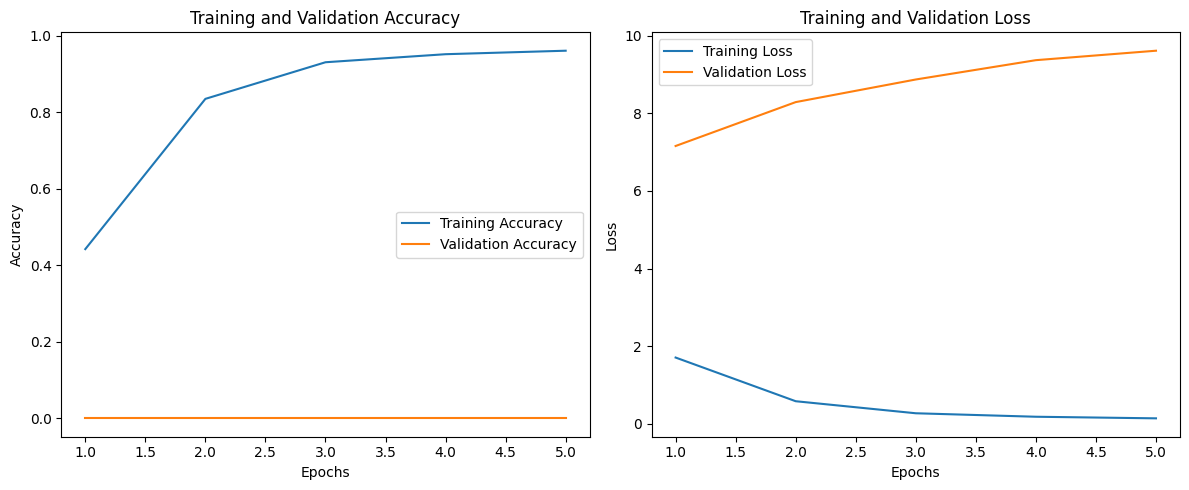

In [25]:
import matplotlib.pyplot as plt

# Extract data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Task 6: Save and Load the Model**

In [26]:
import tensorflow as tf

# Save the model to an HDF5 file
model.save('devnagari_digit_model.keras')
print("Model saved successfully as devnagari_digit_model.h5")

# Task 6 requirement: Load the saved model and re-evaluate
loaded_model = tf.keras.models.load_model('devnagari_digit_model.keras')
load_loss, load_acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Loaded Model Test Accuracy: {load_acc:.4f}")

Model saved successfully as devnagari_digit_model.h5
Loaded Model Test Accuracy: 0.7660


## **Task 7: Predictions**

In [27]:
# Make predictions
predictions = model.predict(X_test[500:505])

# Convert probability distributions to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[500:505], axis=1)

print(f"Predicted Labels: {predicted_labels}")
print(f"Actual Labels:    {true_labels}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Labels: [1 1 1 1 1]
Actual Labels:    [1 1 1 1 1]
